In [ ]:
import pandas as pd
import numpy as np
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# import Google Drive 套件
from google.colab import drive
# 將自己的雲端硬碟掛載上去
drive.mount('/content/gdrive/')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


In [ ]:
# 透過 gdrive/My Drive/... 來存取檔案
train= pd.read_csv('gdrive/My Drive/Colab Notebooks/資料科學/AIDEA/train.csv')#修改為你檔案放的路徑，gdrive/My Drive/指向雲端硬碟的根目錄
test= pd.read_csv('gdrive/My Drive/Colab Notebooks/資料科學/AIDEA/test.csv')
season= pd.read_csv('gdrive/My Drive/Colab Notebooks/資料科學/AIDEA/season.csv')
submission= pd.read_csv('gdrive/My Drive/Colab Notebooks/資料科學/AIDEA/submission.csv')

In [ ]:
train.head()

,yyyy,PerNo,PerStatus,sex,工作分類,職等,廠區代碼,管理層級,工作資歷1,工作資歷2,工作資歷3,工作資歷4,工作資歷5,專案時數,專案總數,當前專案角色,特殊專案佔比,工作地點,訓練時數A,訓練時數B,訓練時數C,生產總額,榮譽數,是否升遷,升遷速度,近三月請假數A,近一年請假數A,近三月請假數B,近一年請假數B,出差數A,出差數B,出差集中度,年度績效等級A,年度績效等級B,年度績效等級C,年齡層級,婚姻狀況,年資層級A,年資層級B,年資層級C,任職前工作平均年數,最高學歷,畢業學校類別,畢業科系類別,眷屬量,通勤成本,歸屬部門
0,2014,1,0,1.0,1.0,3.0,19.0,4.0,0.0,1.0,1.0,0.0,0.0,23.0,1.0,1.0,3.0,6.0,0.0,0.0,5.0,7.0,1.0,1.0,1.0,3.0,5.0,0.0,0.0,5.0,0.0,9.0,2.0,10.0,4.0,6.0,1.0,2.0,1.0,1.0,2.0,NaN,NaN,5.0,0.0,8.0,19138.0
1,2015,1,0,1.0,1.0,3.0,19.0,6.0,0.0,1.0,1.0,0.0,0.0,23.0,2.0,1.0,1.0,6.0,0.0,0.0,8.0,9.0,2.0,0.0,1.0,4.0,6.0,0.0,0.0,3.0,1.0,4.0,2.0,1.0,5.0,7.0,1.0,2.0,2.0,1.0,2.0,NaN,NaN,5.0,2.0,8.0,19138.0
2,2016,1,0,1.0,1.0,3.0,19.0,6.0,0.0,1.0,1.0,0.0,0.0,23.0,3.0,5.0,1.0,6.0,2.0,0.0,5.0,10.0,2.0,0.0,1.0,4.0,7.0,0.0,0.0,2.0,1.0,2.0,2.0,1.0,2.0,7.0,1.0,2.0,2.0,1.0,2.0,NaN,NaN,5.0,2.0,8.0,19138.0
3,2017,1,0,1.0,1.0,3.0,19.0,6.0,0.0,1.0,1.0,0.0,0.0,23.0,4.0,5.0,5.0,6.0,0.0,0.0,10.0,8.0,2.0,0.0,2.0,5.0,5.0,0.0,0.0,2.0,1.0,1.0,2.0,8.0,5.0,7.0,1.0,2.0,2.0,1.0,2.0,NaN,NaN,5.0,2.0,8.0,19138.0
4,2014,3,0,0.0,1.0,4.0,8.0,1.0,0.0,0.0,0.0,0.0,0.0,23.0,4.0,5.0,1.0,6.0,0.0,0.0,1.0,8.0,0.0,0.0,6.0,3.0,6.0,0.0,0.0,0.0,0.0,0.0,6.0,4.0,2.0,9.0,1.0,5.0,5.0,0.0,0.0,2.0,4.0,1.0,2.0,8.0,8181.0


In [ ]:
print(train.dtypes)

yyyy           int64
PerNo          int64
PerStatus      int64
sex          float64
工作分類         float64
職等           float64
廠區代碼         float64
管理層級         float64
工作資歷1        float64
工作資歷2        float64
工作資歷3        float64
工作資歷4        float64
工作資歷5        float64
專案時數         float64
專案總數         float64
當前專案角色       float64
特殊專案佔比       float64
工作地點         float64
訓練時數A        float64
訓練時數B        float64
訓練時數C        float64
生產總額         float64
榮譽數          float64
是否升遷         float64
升遷速度         float64
近三月請假數A      float64
近一年請假數A      float64
近三月請假數B      float64
近一年請假數B      float64
出差數A         float64
出差數B         float64
出差集中度        float64
年度績效等級A      float64
年度績效等級B      float64
年度績效等級C      float64
年齡層級         float64
婚姻狀況         float64
年資層級A        float64
年資層級B        float64
年資層級C        float64
任職前工作平均年數    float64
最高學歷         float64
畢業學校類別       float64
畢業科系類別       float64
眷屬量          float64
通勤成本         float64
歸屬部門         float64
dtype: object

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14392 entries, 0 to 14391
Data columns (total 47 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   yyyy       14392 non-null  int64  
 1   PerNo      14392 non-null  int64  
 2   PerStatus  14392 non-null  int64  
 3   sex        14319 non-null  float64
 4   工作分類       14319 non-null  float64
 5   職等         14319 non-null  float64
 6   廠區代碼       14319 non-null  float64
 7   管理層級       14319 non-null  float64
 8   工作資歷1      14319 non-null  float64
 9   工作資歷2      14319 non-null  float64
 10  工作資歷3      14319 non-null  float64
 11  工作資歷4      14319 non-null  float64
 12  工作資歷5      14319 non-null  float64
 13  專案時數       14319 non-null  float64
 14  專案總數       14319 non-null  float64
 15  當前專案角色     14319 non-null  float64
 16  特殊專案佔比     14319 non-null  float64
 17  工作地點       14319 non-null  float64
 18  訓練時數A      14319 non-null  float64
 19  訓練時數B      14319 non-null  float64
 20  訓練時數C 

In [ ]:
print(train.columns.values)

['yyyy' 'PerNo' 'PerStatus' 'sex' '工作分類' '職等' '廠區代碼' '管理層級' '工作資歷1'
 '工作資歷2' '工作資歷3' '工作資歷4' '工作資歷5' '專案時數' '專案總數' '當前專案角色' '特殊專案佔比' '工作地點'
 '訓練時數A' '訓練時數B' '訓練時數C' '生產總額' '榮譽數' '是否升遷' '升遷速度' '近三月請假數A' '近一年請假數A'
 '近三月請假數B' '近一年請假數B' '出差數A' '出差數B' '出差集中度' '年度績效等級A' '年度績效等級B' '年度績效等級C'
 '年齡層級' '婚姻狀況' '年資層級A' '年資層級B' '年資層級C' '任職前工作平均年數' '最高學歷' '畢業學校類別'
 '畢業科系類別' '眷屬量' '通勤成本' '歸屬部門']


In [ ]:
# to get information three quartiles, mean, count, minimum and maximum values and the standard deviation.
train.describe()

,yyyy,PerNo,PerStatus,sex,工作分類,職等,廠區代碼,管理層級,工作資歷1,工作資歷2,工作資歷3,工作資歷4,工作資歷5,專案時數,專案總數,當前專案角色,特殊專案佔比,工作地點,訓練時數A,訓練時數B,訓練時數C,生產總額,榮譽數,是否升遷,升遷速度,近三月請假數A,近一年請假數A,近三月請假數B,近一年請假數B,出差數A,出差數B,出差集中度,年度績效等級A,年度績效等級B,年度績效等級C,年齡層級,婚姻狀況,年資層級A,年資層級B,年資層級C,任職前工作平均年數,最高學歷,畢業學校類別,畢業科系類別,眷屬量,通勤成本,歸屬部門
count,14392.000000,14392.000000,14392.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,14319.000000,9066.000000,10551.000000,14319.000000,14319.000000,14319.000000,14319.000000
mean,2015.520220,4410.755489,0.055309,0.701306,1.109365,4.375655,12.833927,1.791885,0.029122,0.051749,0.060549,0.056219,0.228787,22.216915,2.083106,4.019764,1.656610,5.806551,0.485369,0.277533,1.780711,7.267058,0.495845,0.070675,2.506809,3.187583,6.518542,0.040785,0.061946,1.522662,0.286053,1.396606,5.061736,4.584189,3.591871,7.347999,1.257909,3.619806,3.100286,1.151477,0.737831,2.054048,3.491044,5.686221,1.072561,8.333124,12932.624206
std,1.116459,2530.042411,0.228589,0.457701,0.312108,1.736769,5.634432,1.543562,0.168155,0.221528,0.238509,0.230352,0.420066,2.501938,1.037672,1.679299,2.986239,1.317629,1.182728,1.055225,1.459646,11.482640,0.902941,0.256291,1.592014,1.787772,1.582195,0.378034,0.504627,1.251187,0.616978,1.901997,3.357015,3.298976,1.352748,2.736749,0.439569,1.769711,1.774830,1.454685,0.762465,0.312546,0.866923,2.417362,0.923064,1.247291,5625.608973
min,2014.000000,1.000000,0.000000,0.000000,1.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,4.000000,2029.000000
25%,2015.000000,2237.000000,0.000000,0.000000,1.000000,3.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,1.000000,3.000000,0.000000,6.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,1.000000,2.000000,6.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2.000000,1.000000,2.000000,5.000000,1.000000,2.000000,2.000000,0.000000,0.000000,2.000000,3.000000,3.000000,0.000000,8.000000,8145.000000
50%,2016.000000,4387.000000,0.000000,1.000000,1.000000,4.000000,14.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.000000,2.000000,5.000000,1.000000,6.000000,0.000000,0.000000,1.000000,4.000000,0.000000,0.000000,2.000000,3.000000,6.000000,0.000000,0.000000,1.000000,0.000000,1.000000,5.000000,4.000000,4.000000,7.000000,1.000000,3.000000,3.000000,1.000000,1.000000,2.000000,4.000000,6.000000,1.000000,8.000000,14040.000000
75%,2017.000000,6613.250000,0.000000,1.000000,1.000000,7.000000,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.000000,3.000000,5.000000,2.000000,6.000000,0.000000,0.000000,2.000000,9.000000,1.000000,0.000000,3.000000,4.000000,7.000000,0.000000,0.000000,2.000000,0.000000,2.000000,9.000000,8.000000,5.000000,10.000000,2.000000,5.000000,4.000000,2.000000,1.000000,2.000000,4.000000,8.000000,2.000000,8.000000,18111.000000
max,2017.000000,8775.000000,1.000000,1.000000,2.000000,8.000000,20.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,25.000000,8.000000,5.000000,15.000000,11.000000,15.000000,15.000000,15.000000,100.000000,9.000000,1.000000,10.000000,15.000000,12.000000,8.000000,8.000000,10.000000,10.000000,14.000000,10.000000,10.000000,5.000000,13.000000,3.000000,9.000000,8.000000,9.000000,7.000000,3.000000,5.000000,9.000000,3.000000,16.000000,20208.000000


In [ ]:
train.shape

(14392, 47)

In [ ]:
test.shape

(3739, 47)

In [ ]:
train.isnull().sum()

yyyy            0
PerNo           0
PerStatus       0
sex            73
工作分類           73
職等             73
廠區代碼           73
管理層級           73
工作資歷1          73
工作資歷2          73
工作資歷3          73
工作資歷4          73
工作資歷5          73
專案時數           73
專案總數           73
當前專案角色         73
特殊專案佔比         73
工作地點           73
訓練時數A          73
訓練時數B          73
訓練時數C          73
生產總額           73
榮譽數            73
是否升遷           73
升遷速度           73
近三月請假數A        73
近一年請假數A        73
近三月請假數B        73
近一年請假數B        73
出差數A           73
出差數B           73
出差集中度          73
年度績效等級A        73
年度績效等級B        73
年度績效等級C        73
年齡層級           73
婚姻狀況           73
年資層級A          73
年資層級B          73
年資層級C          73
任職前工作平均年數      73
最高學歷         5326
畢業學校類別       3841
畢業科系類別         73
眷屬量            73
通勤成本           73
歸屬部門           73
dtype: int64

In [ ]:
test.isnull().sum()

yyyy            0
PerNo           0
PerStatus    3739
sex            18
工作分類           18
職等             18
廠區代碼           18
管理層級           18
工作資歷1          18
工作資歷2          18
工作資歷3          18
工作資歷4          18
工作資歷5          18
專案時數           18
專案總數           18
當前專案角色         18
特殊專案佔比         18
工作地點           18
訓練時數A          18
訓練時數B          18
訓練時數C          18
生產總額           18
榮譽數            18
是否升遷           18
升遷速度           18
近三月請假數A        18
近一年請假數A        18
近三月請假數B        18
近一年請假數B        18
出差數A           18
出差數B           18
出差集中度          18
年度績效等級A        18
年度績效等級B        18
年度績效等級C        18
年齡層級           18
婚姻狀況           18
年資層級A          18
年資層級B          18
年資層級C          18
任職前工作平均年數      18
最高學歷         1384
畢業學校類別       1067
畢業科系類別         18
眷屬量            18
通勤成本           18
歸屬部門           18
dtype: int64

In [ ]:
train = train.drop('yyyy', axis = 1)
train = train.drop('PerNo', axis = 1)
train = train.drop('最高學歷', axis = 1)
train = train.drop('畢業學校類別', axis = 1)
train = train.drop('畢業科系類別', axis = 1)

test = test.drop('yyyy', axis = 1)
test = test.drop('PerNo', axis = 1)
test = test.drop('最高學歷', axis = 1)
test = test.drop('畢業學校類別', axis = 1)
test = test.drop('畢業科系類別', axis = 1)


In [ ]:
# 用"眾數"進行補值
train['sex'] = train['sex'].fillna(value=1)
train['工作分類'] = train['工作分類'].fillna(value=1)
train['職等'] = train['職等'].fillna(value=4)
train['廠區代碼'] = train['廠區代碼'].fillna(value=8)
train['管理層級'] = train['管理層級'].fillna(value=1)
train['工作資歷1'] = train['工作資歷1'].fillna(value=0)
train['工作資歷2'] = train['工作資歷2'].fillna(value=0)
train['工作資歷3'] = train['工作資歷3'].fillna(value=0)
train['工作資歷4'] = train['工作資歷4'].fillna(value=0)
train['工作資歷5'] = train['工作資歷5'].fillna(value=0)
train['當前專案角色'] = train['當前專案角色'].fillna(value=5)
train['工作地點'] = train['工作地點'].fillna(value=6)
train['是否升遷'] = train['是否升遷'].fillna(value=0)
train['年度績效等級A'] = train['年度績效等級A'].fillna(value=10)
train['年度績效等級B'] = train['年度績效等級B'].fillna(value=1)
train['年度績效等級C'] = train['年度績效等級C'].fillna(value=5)
train['年齡層級'] = train['年齡層級'].fillna(value=6)
train['婚姻狀況'] = train['婚姻狀況'].fillna(value=1)
train['年資層級A'] = train['年資層級A'].fillna(value=2)
train['年資層級B'] = train['年資層級B'].fillna(value=2)
train['年資層級C'] = train['年資層級C'].fillna(value=0)
train['歸屬部門'] = train['歸屬部門'].fillna(value=14040)

In [ ]:
# 用"平均值"進行補值
train['專案時數'] = train['專案時數'].fillna(train['專案時數'].mean())
train['專案總數'] = train['專案總數'].fillna(train['專案總數'].mean())
train['特殊專案佔比'] = train['特殊專案佔比'].fillna(train['特殊專案佔比'].mean())
train['訓練時數A'] = train['訓練時數A'].fillna(train['訓練時數A'].mean())
train['訓練時數B'] = train['訓練時數B'].fillna(train['訓練時數B'].mean())
train['訓練時數C'] = train['訓練時數C'].fillna(train['訓練時數C'].mean())
train['生產總額'] = train['生產總額'].fillna(train['生產總額'].mean())
train['榮譽數'] = train['榮譽數'].fillna(train['榮譽數'].mean())
train['升遷速度'] = train['升遷速度'].fillna(train['升遷速度'].mean())
train['近三月請假數A'] = train['近三月請假數A'].fillna(train['近三月請假數A'].mean())
train['近一年請假數A'] = train['近一年請假數A'].fillna(train['近一年請假數A'].mean())
train['近三月請假數B'] = train['近三月請假數B'].fillna(train['近三月請假數B'].mean())
train['近一年請假數B'] = train['近一年請假數B'].fillna(train['近一年請假數B'].mean())
train['出差數A'] = train['出差數A'].fillna(train['出差數A'].mean())
train['出差數B'] = train['出差數B'].fillna(train['出差數B'].mean())
train['出差集中度'] = train['出差集中度'].fillna(train['出差集中度'].mean())
train['任職前工作平均年數'] = train['任職前工作平均年數'].fillna(train['任職前工作平均年數'].mean())
train['眷屬量'] = train['眷屬量'].fillna(train['眷屬量'].mean())
train['通勤成本'] = train['通勤成本'].fillna(train['通勤成本'].mean())


In [ ]:
# 用"眾數"進行補值
test['sex'] = test['sex'].fillna(value=1)
test['工作分類'] = test['工作分類'].fillna(value=1)
test['職等'] = test['職等'].fillna(value=4)
test['廠區代碼'] = test['廠區代碼'].fillna(value=8)
test['管理層級'] = test['管理層級'].fillna(value=1)
test['工作資歷1'] = test['工作資歷1'].fillna(value=0)
test['工作資歷2'] = test['工作資歷2'].fillna(value=0)
test['工作資歷3'] = test['工作資歷3'].fillna(value=0)
test['工作資歷4'] = test['工作資歷4'].fillna(value=0)
test['工作資歷5'] = test['工作資歷5'].fillna(value=0)
test['當前專案角色'] = test['當前專案角色'].fillna(value=5)
test['工作地點'] = test['工作地點'].fillna(value=6)
test['是否升遷'] = test['是否升遷'].fillna(value=0)
test['年度績效等級A'] = test['年度績效等級A'].fillna(value=10)
test['年度績效等級B'] = test['年度績效等級B'].fillna(value=1)
test['年度績效等級C'] = test['年度績效等級C'].fillna(value=5)
test['年齡層級'] = test['年齡層級'].fillna(value=6)
test['婚姻狀況'] = test['婚姻狀況'].fillna(value=1)
test['年資層級A'] = test['年資層級A'].fillna(value=2)
test['年資層級B'] = test['年資層級B'].fillna(value=2)
test['年資層級C'] = test['年資層級C'].fillna(value=0)
test['歸屬部門'] = test['歸屬部門'].fillna(value=14040)


In [ ]:
# 用"平均值"進行補值
test['專案時數'] = test['專案時數'].fillna(test['專案時數'].mean())
test['專案總數'] = test['專案總數'].fillna(test['專案總數'].mean())
test['特殊專案佔比'] = test['特殊專案佔比'].fillna(test['特殊專案佔比'].mean())
test['訓練時數A'] = test['訓練時數A'].fillna(test['訓練時數A'].mean())
test['訓練時數B'] = test['訓練時數B'].fillna(test['訓練時數B'].mean())
test['訓練時數C'] = test['訓練時數C'].fillna(test['訓練時數C'].mean())
test['生產總額'] = test['生產總額'].fillna(test['生產總額'].mean())
test['榮譽數'] = test['榮譽數'].fillna(test['榮譽數'].mean())
test['升遷速度'] = test['升遷速度'].fillna(test['升遷速度'].mean())
test['近三月請假數A'] = test['近三月請假數A'].fillna(test['近三月請假數A'].mean())
test['近一年請假數A'] = test['近一年請假數A'].fillna(test['近一年請假數A'].mean())
test['近三月請假數B'] = test['近三月請假數B'].fillna(test['近三月請假數B'].mean())
test['近一年請假數B'] = test['近一年請假數B'].fillna(test['近一年請假數B'].mean())
test['出差數A'] = test['出差數A'].fillna(test['出差數A'].mean())
test['出差數B'] = test['出差數B'].fillna(test['出差數B'].mean())
test['出差集中度'] = test['出差集中度'].fillna(test['出差集中度'].mean())
test['任職前工作平均年數'] = test['任職前工作平均年數'].fillna(test['任職前工作平均年數'].mean())
test['眷屬量'] = test['眷屬量'].fillna(test['眷屬量'].mean())
test['通勤成本'] = test['通勤成本'].fillna(test['通勤成本'].mean())


In [ ]:
train.isnull().sum()

PerStatus    0
sex          0
工作分類         0
職等           0
廠區代碼         0
管理層級         0
工作資歷1        0
工作資歷2        0
工作資歷3        0
工作資歷4        0
工作資歷5        0
專案時數         0
專案總數         0
當前專案角色       0
特殊專案佔比       0
工作地點         0
訓練時數A        0
訓練時數B        0
訓練時數C        0
生產總額         0
榮譽數          0
是否升遷         0
升遷速度         0
近三月請假數A      0
近一年請假數A      0
近三月請假數B      0
近一年請假數B      0
出差數A         0
出差數B         0
出差集中度        0
年度績效等級A      0
年度績效等級B      0
年度績效等級C      0
年齡層級         0
婚姻狀況         0
年資層級A        0
年資層級B        0
年資層級C        0
任職前工作平均年數    0
眷屬量          0
通勤成本         0
歸屬部門         0
dtype: int64

In [ ]:
test.isnull().sum()

PerStatus    3739
sex             0
工作分類            0
職等              0
廠區代碼            0
管理層級            0
工作資歷1           0
工作資歷2           0
工作資歷3           0
工作資歷4           0
工作資歷5           0
專案時數            0
專案總數            0
當前專案角色          0
特殊專案佔比          0
工作地點            0
訓練時數A           0
訓練時數B           0
訓練時數C           0
生產總額            0
榮譽數             0
是否升遷            0
升遷速度            0
近三月請假數A         0
近一年請假數A         0
近三月請假數B         0
近一年請假數B         0
出差數A            0
出差數B            0
出差集中度           0
年度績效等級A         0
年度績效等級B         0
年度績效等級C         0
年齡層級            0
婚姻狀況            0
年資層級A           0
年資層級B           0
年資層級C           0
任職前工作平均年數       0
眷屬量             0
通勤成本            0
歸屬部門            0
dtype: int64

In [ ]:
X_train = train.drop("PerStatus", axis= 1) #定義特徵變數
Y_train = train["PerStatus"]
X_test = test.drop("PerStatus", axis= 1) #定義特徵變數
Y_test = test["PerStatus"]

##找特徵

In [ ]:
import statsmodels.api as sm

In [ ]:
def stepwise_selection(X_train, PerStatus,SL_in=0.05,SL_out = 0.05):
    initial_features = X_train.columns.tolist()
    best_features = []
    while (len(initial_features)>0):
        remaining_features = list(set(initial_features)-set(best_features))
        new_pval = pd.Series(index=remaining_features)
        for new_column in remaining_features:
            model = sm.OLS(PerStatus.astype(float), sm.add_constant(X_train[best_features+[new_column]]).astype(float)).fit()
            new_pval[new_column] = model.pvalues[new_column]
        min_p_value = new_pval.min()
        if(min_p_value<SL_in):
            best_features.append(new_pval.idxmin())
            while(len(best_features)>0):
                best_features_with_constant = sm.add_constant(X_train[best_features].astype(float))
                p_values = sm.OLS(PerStatus, best_features_with_constant).fit().pvalues[1:]
                max_p_value = p_values.max()
                if(max_p_value >= SL_out):
                    excluded_feature = p_values.idxmax()
                    best_features.remove(excluded_feature)
                else:
                    break 
        else:
            break
    return best_features

In [ ]:
stepwise_selection(X_train,Y_train)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  


['近一年請假數B',
 '年度績效等級C',
 'sex',
 '眷屬量',
 '特殊專案佔比',
 '專案時數',
 '訓練時數C',
 '年齡層級',
 '出差數B',
 '年資層級B',
 '工作資歷5',
 '近一年請假數A',
 '近三月請假數A',
 '婚姻狀況',
 '專案總數',
 '管理層級']

In [ ]:
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

target = train["PerStatus"].values
features = train[['近一年請假數B',
           '年度績效等級C',
           'sex',
           '眷屬量',
           '特殊專案佔比',
           '專案時數',
           '訓練時數C',
           '年齡層級',
           '出差數B',
           '年資層級B',
           '工作資歷5',
           '近一年請假數A',
           '近三月請假數A',
           '婚姻狀況',
           '專案總數',
           '管理層級']]

##OverSampling

In [ ]:
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score
from numpy import mean

In [ ]:
train['PerStatus'].value_counts()/len(train)

0    0.944691
1    0.055309
Name: PerStatus, dtype: float64

In [ ]:
train['PerStatus'].value_counts()

0    13596
1      796
Name: PerStatus, dtype: int64

In [ ]:
#import pandas as pd
#import numpy as np

#from imblearn.over_sampling import SMOTE
#smote = SMOTE(k_neighbors=5, random_state=42)
#X_res, Y_res = smote.fit_resample(X_train, Y_train)


In [ ]:
#from sklearn.model_selection import train_test_split
  
# split into 70:30 ration
#_train, X_test, Y_train, Y_test = train_test_split(features,target, test_size = 0.3, random_state = 0)

#smt = SMOTE(random_state=0)
#data_X,data_y=smt.fit_sample(X_train, y_train)
# describes info about train and test set
print("Number transactions X_train dataset: ", X_train.shape)
print("Number transactions Y_train dataset: ", Y_train.shape)
print("Number transactions X_test dataset: ", X_test.shape)
print("Number transactions Y_test dataset: ", Y_test.shape)

Number transactions X_train dataset:  (14392, 41)
Number transactions Y_train dataset:  (14392,)
Number transactions X_test dataset:  (3739, 41)
Number transactions Y_test dataset:  (3739,)


In [ ]:
from imblearn.over_sampling import SMOTE

print('重新採樣前：')
print('正樣本數：',len(Y_train[Y_train==0]))
print('負樣本數：',len(Y_train[Y_train==1]))

sm=SMOTE(random_state=0)
X_re_train,Y_re_train=sm.fit_resample(X_train,Y_train)

print('重新採樣後：')
print('正樣本數：',len(Y_re_train[Y_re_train==0]))
print('負樣本數：',len(Y_re_train[Y_re_train==1]))


重新採樣前：
正樣本數： 13596
負樣本數： 796
重新採樣後：
正樣本數： 13596
負樣本數： 13596


In [ ]:
#from imblearn.over_sampling import SMOTE

#print('重新採樣前：')

#print('正樣本數：',len(Y_test[Y_test==0]))
#print('負樣本數：',len(Y_test[Y_test==1]))
#sm=SMOTE(random_state=0)

#print('重新採樣後：')
#print('正樣本數：',len(Y_re_test[Y_re_test==0]))
#print('負樣本數：',len(Y_re_test[Y_re_test==1]))

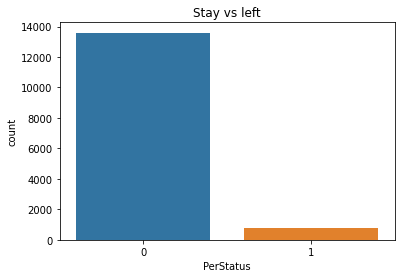

In [ ]:
sns.countplot(x='PerStatus',data=train)
plt.title('Stay vs left')
plt.show()

In [ ]:
train['PerStatus'].value_counts()

0    13596
1      796
Name: PerStatus, dtype: int64

In [ ]:
test['PerStatus'].value_counts()

Series([], Name: PerStatus, dtype: int64)

##學姊方法

In [ ]:
# Build test and training test
#X_train,X_test,y_train,y_test = train_test_split(features,target,test_size=0.3,random_state=42)


decision_tree = tree.DecisionTreeClassifier(random_state=1,criterion = 'entropy',min_samples_split = 100)


decision_tree_ = decision_tree.fit(X_re_train,Y_re_train)
target_predict=decision_tree_.predict(X_test)


In [ ]:
import numpy as np
np.set_printoptions(threshold=np.inf)

In [ ]:
import pandas as pd
#显示所有列
pd.set_option('display.max_columns', None)
#显示所有行
pd.set_option('display.max_rows', None)
#设置value的显示长度为100，默认为50
pd.set_option('max_colwidth',10000)

In [ ]:
print(target_predict)

[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

In [ ]:
import numpy as np 
import pandas as pd 
prediction = pd.DataFrame(target_predict,columns=['PerStatus']).to_csv('gdrive/My Drive/Colab Notebooks/資料科學/AIDEA/學姊_predict.csv') 

**Decision Tree決策樹**

In [ ]:
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

target = train['PerStatus'].values
data_features_names = ['sex', '工作資歷1', '工作資歷5', '近三月請假數B', '近一年請假數B', '婚姻狀況']
features = train[data_features_names].values

#Build test and training test
X_re_train,X_re_test,Y_re_train,Y_re_test = train_test_split(features,target,test_size=0.3,random_state=42)

decision_tree = tree.DecisionTreeClassifier(random_state=1,criterion = 'entropy',min_samples_split = 100)


decision_tree_ = decision_tree.fit(X_re_train,Y_re_train)
target_predict=decision_tree_.predict(X_test)

#print("Decision tree score: ",accuracy_score(Y_test,target_predict))

from sklearn.metrics import mean_squared_error, r2_score
print ("MSE    :",mean_squared_error(Y_test,target_predict))
print ("R2     :",r2_score(Y_test,target_predict))

ValueError: ignored

In [ ]:
import numpy as np
np.set_printoptions(threshold=np.inf)

In [ ]:
import pandas as pd
#显示所有列
pd.set_option('display.max_columns', None)
#显示所有行
pd.set_option('display.max_rows', None)
#设置value的显示长度为100，默认为50
pd.set_option('max_colwidth',5000)

In [ ]:
print(target_predict)

In [ ]:
import numpy as np
import pandas as pd
prediction = pd.DataFrame(target_predict, columns=['predictions']).to_csv('gdrive/My Drive/Colab Notebooks/資料科學/AIDEA/Decision_tree_score_predict.csv')

##generalized_tree

In [ ]:
import graphviz
generalized_tree = tree.DecisionTreeClassifier(
        random_state = 1,
        max_depth = 5,
        min_samples_split=2
)

generalized_tree_ = generalized_tree.fit(features,target)

print("Generalized tree score: ", generalized_tree_.score(features,target))




dot_data=tree.export_graphviz(generalized_tree_,feature_names=data_features_names,out_file=None)
graph = graphviz.Source(dot_data)
graph


In [ ]:
graph.save('new_decion tree.png')

In [ ]:
import numpy as np
np.set_printoptions(threshold=np.inf)

In [ ]:
import pandas as pd
#显示所有列
pd.set_option('display.max_columns', None)
#显示所有行
pd.set_option('display.max_rows', None)
#设置value的显示长度为100，默认为50
pd.set_option('max_colwidth',10000)

In [ ]:
print(target_predict)

In [ ]:
import numpy as np
import pandas as pd
prediction = pd.DataFrame(target_predict, columns=['predictions']).to_csv('gdrive/My Drive/Colab Notebooks/資料科學/AIDEA/Generalized_tree_score_predict.csv')

##RFE


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

target = train['PerStatus'].values
data_features_names = ['sex', '工作資歷1', '工作資歷5', '近三月請假數B', '近一年請假數B', '婚姻狀況']
features = train[data_features_names].values

#Build test and training test
#X_train,X_test,y_train,y_test = train_test_split(features,target,test_size=1,random_state=42)
#X_re_train,X_re_test,Y_re_train,Y_re_test = train_test_split(features,target,test_size=0.3,random_state=42)
my_forest = RandomForestClassifier(max_depth=5, min_samples_split=10, n_estimators=500, random_state=5,criterion = 'entropy')


my_forest_ = my_forest.fit(X_re_train,Y_re_train)
target_predict=my_forest_.predict(X_test)

print("Random forest score: ",accuracy_score(Y_test,target_predict))

from sklearn.metrics import mean_squared_error, r2_score
print ("MSE    :",mean_squared_error(Y_test,target_predict))
print ("R2     :",r2_score(Y_test,target_predict))

In [ ]:
import numpy as np
np.set_printoptions(threshold=np.inf)

In [ ]:
import pandas as pd
#显示所有列
pd.set_option('display.max_columns', None)
#显示所有行
pd.set_option('display.max_rows', None)
#设置value的显示长度为100，默认为50
pd.set_option('max_colwidth',5000)

In [ ]:
print(target_predict)

In [ ]:
import numpy as np
import pandas as pd
prediction = pd.DataFrame(target_predict, columns=['predictions']).to_csv('gdrive/My Drive/Colab Notebooks/資料科學/AIDEA/RFE_tree_score_predict.csv')

##F score


In [1]:
!pip install scikit-plot

In [2]:
import scikitplot as skplt
skplt.metrics.plot_confusion_matrix(X_test, target_predict,
                  #cmap=plt.cm.BuGn,
                  #title = "test",
                  #figsize=(3,3))
#plt.show()

SyntaxError: ignored

In [ ]:
from datetime import datetime
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score


print(accuracy_score(Y_test, target_predict))  # 0.5
print(accuracy_score(Y_test, target_predict, normalize=False))  # 2

# 在具有二元标签指示符的多标签分类案例中
print(accuracy_score(np.array([[0, 1], [1, 1]]), np.ones((2, 2))))  # 0.5


In [ ]:
from sklearn.metrics import precision_score

print(precision_score(Y_test, target_predict, average='macro')) 
print(precision_score(Y_test, target_predict, average='micro'))  
print(precision_score(Y_test, target_predict, average='weighted')) 
print(precision_score(Y_test, target_predict, average=None)) 


In [ ]:
from sklearn.metrics import recall_score


print(recall_score(Y_test, target_predict, average='macro'))  
print(recall_score(Y_test, target_predict, average='micro')) 
print(recall_score(Y_test, target_predict, average='weighted')) 
print(recall_score(Y_test, target_predict, average=None)) 


In [ ]:
from sklearn.metrics import f1_score


print(f1_score(Y_test, target_predict, average='macro'))  
print(f1_score(Y_test, target_predict, average='micro'))  
print(f1_score(Y_test, target_predict, average='weighted'))  
print(f1_score(Y_test, target_predict, average=None))  
